## Import and load the data

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import h5py

def get_dataset_name(file_name_with_dir):
    filename_without_dir = file_name_with_dir.split('/')[-1]
    temp = filename_without_dir.split('_')[:-1]
    dataset_name = "_".join(temp)
    return dataset_name

----
## Data preprocessing


### Downsampling
! **Important**: every 10th observation is made. Now it looks like the new series of observations is only the first 10% of the length but in reality there are 10 steps in between observations

In [ ]:
# Downsample the data, for now take every 10th time point and save to new directory

DOWNSAMPLING_STEP = 10
dir_root = "/Users/stijnroos/VisualStudio/DL_data/"
dir_intra = dir_root + "Intra/train/"
dir_intra_downsampled = dir_root + "Intra/train_downsampled/"

if not os.path.exists(dir_intra_downsampled):
    # read the scaled data from before and downsample it
    os.makedirs(dir_intra_downsampled)
    filenames = [f for f in os.listdir(dir_intra) if f.endswith('.h5')]

    for i, filename in enumerate(filenames):
        filepath_in = dir_intra + filename
        filepath_out = dir_intra_downsampled + filename
        
        with h5py.File(filepath_in, 'r') as f_in:
            dataset_name = list(f_in.keys())[0]
            data = f_in[dataset_name][()]
            
            # Downsample the data (take every 10th time point)
            data_downsampled = data[:, ::DOWNSAMPLING_STEP]  # Keep all sensors, downsample time
            
            # Save the downsampled data
            with h5py.File(filepath_out, 'w') as f_out:
                f_out.create_dataset(dataset_name, data=data_downsampled)
else:
    print("Directory already exists: skipping downsampling step")

# here print one shape of the downsampled files for verification
dir_intra_downsampled = dir_root + "Intra/train_downsampled/"
sample_file = dir_intra_downsampled + os.listdir(dir_intra_downsampled)[0]
with h5py.File(sample_file, 'r') as f:
    dataset_name = list(f.keys())[0]
    data = f[dataset_name][()]
    print(f"Sample file: {sample_file} \n --> Shape of downsampled data: {data.shape}\n --> Shape of original data: (248, 35624)")

Sample file: /Users/stijnroos/VisualStudio/DL_data/Intra/train_scaled_downsampled/rest_105923_8.h5 
 --> Shape of downsampled data: (248, 3563)
 --> Shape of original data: (248, 35624)



### Min-Max scaler

In [ ]:
# scale the training data using minmax
import json
dir_intra = dir_root + "Intra/train/"
dir_intra_scaled = dir_root + "Intra/train_scaled/"
scaler_stats_file = dir_root + "Intra/scaler_stats.json"

if not os.path.exists(dir_intra_scaled):
    os.makedirs(dir_intra_scaled)

    filenames = [f for f in os.listdir(dir_intra) if f.endswith('.h5')]
    
    # First pass: calculate global min/max across all training files
    global_min = float('inf')
    global_max = float('-inf')
    
    for filename in filenames:
        filepath_in = dir_intra + filename
        with h5py.File(filepath_in, 'r') as f_in:
            dataset_name = list(f_in.keys())[0]
            data = f_in[dataset_name][()]
            global_min = min(global_min, float(data.min()))
            global_max = max(global_max, float(data.max()))
    
    # Second pass: scale all files using the global min/max
    for i, filename in enumerate(filenames):
        filepath_in = dir_intra + filename
        filepath_out = dir_intra_scaled + filename
        
        with h5py.File(filepath_in, 'r') as f_in:
            dataset_name = list(f_in.keys())[0]
            data = f_in[dataset_name][()]
            
            # Scale the data using global min/max
            data_scaled = (data - global_min) / (global_max - global_min + 1e-8)
            
            # Save the scaled data
            with h5py.File(filepath_out, 'w') as f_out:
                f_out.create_dataset(dataset_name, data=data_scaled)
    
    # Save global scaler stats to file
    scaler_stats = {"global": {"min": global_min, "max": global_max}}
    with open(scaler_stats_file, 'w') as f:
        json.dump(scaler_stats, f)
else:
    print("Directory already exists: skipping scaling step")


## Data visualisation

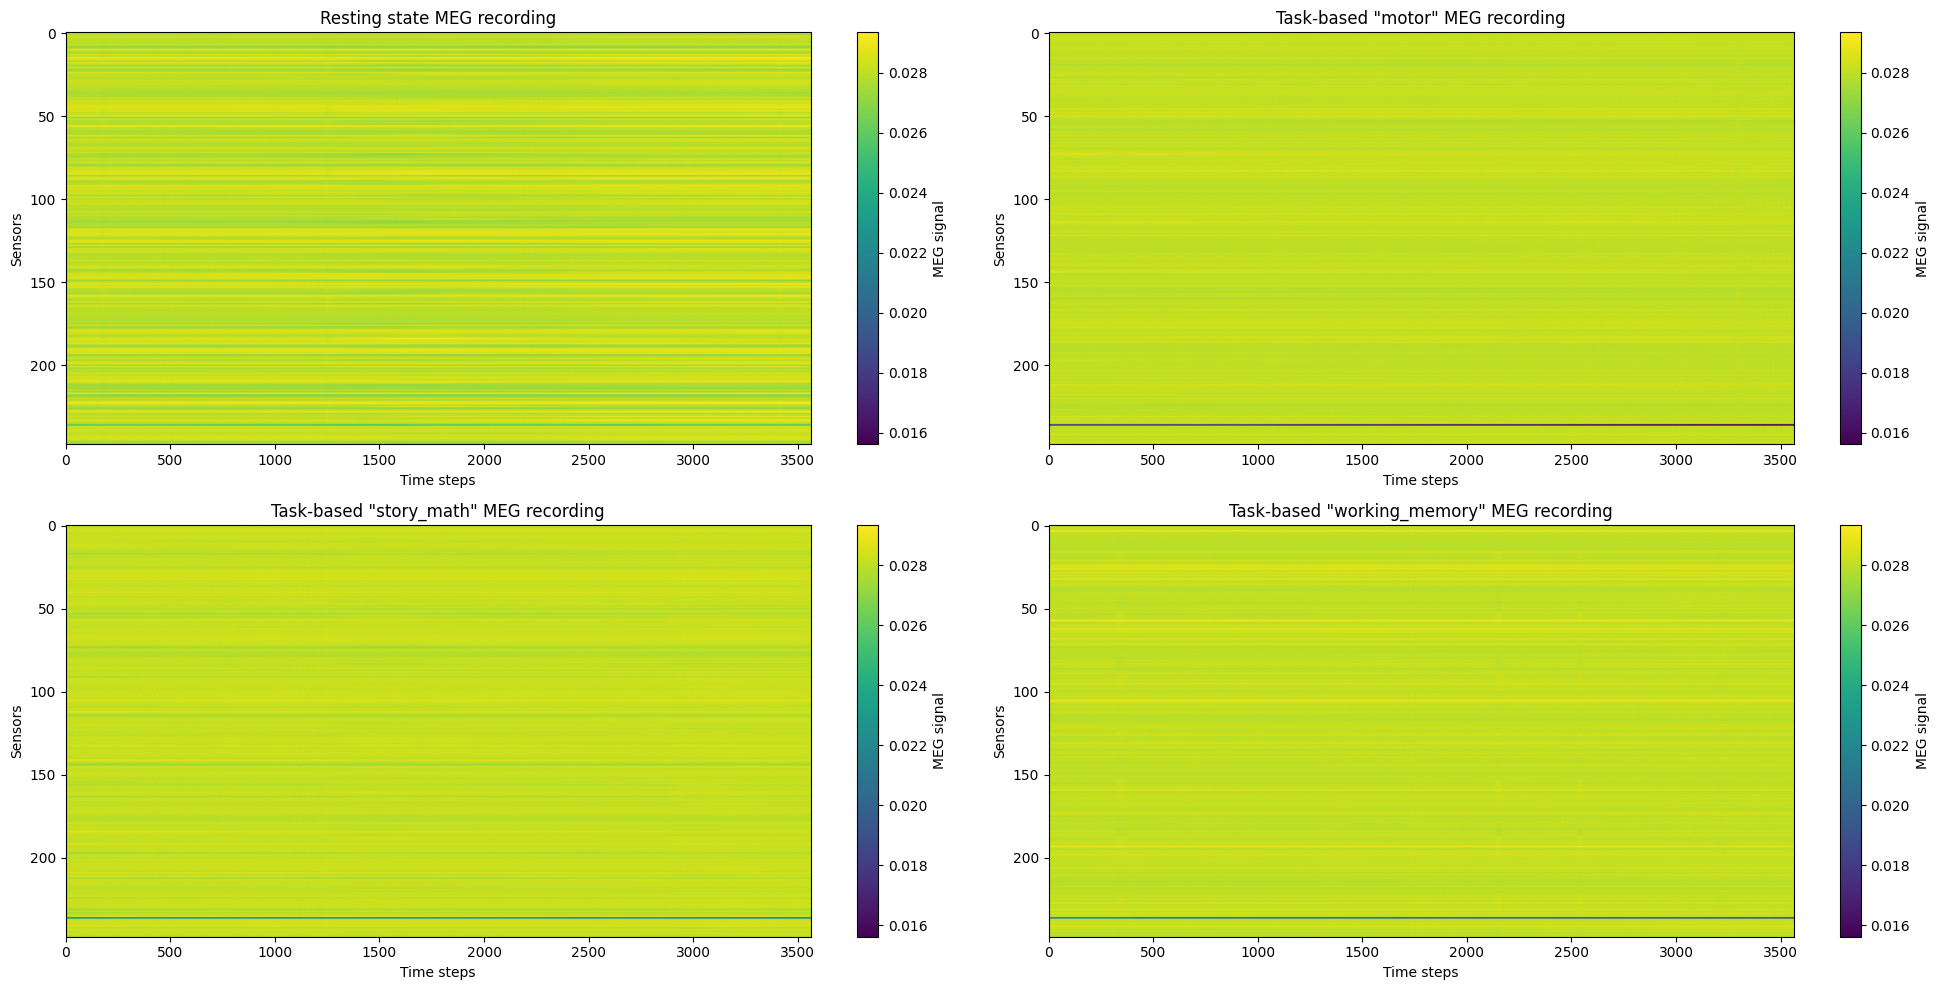

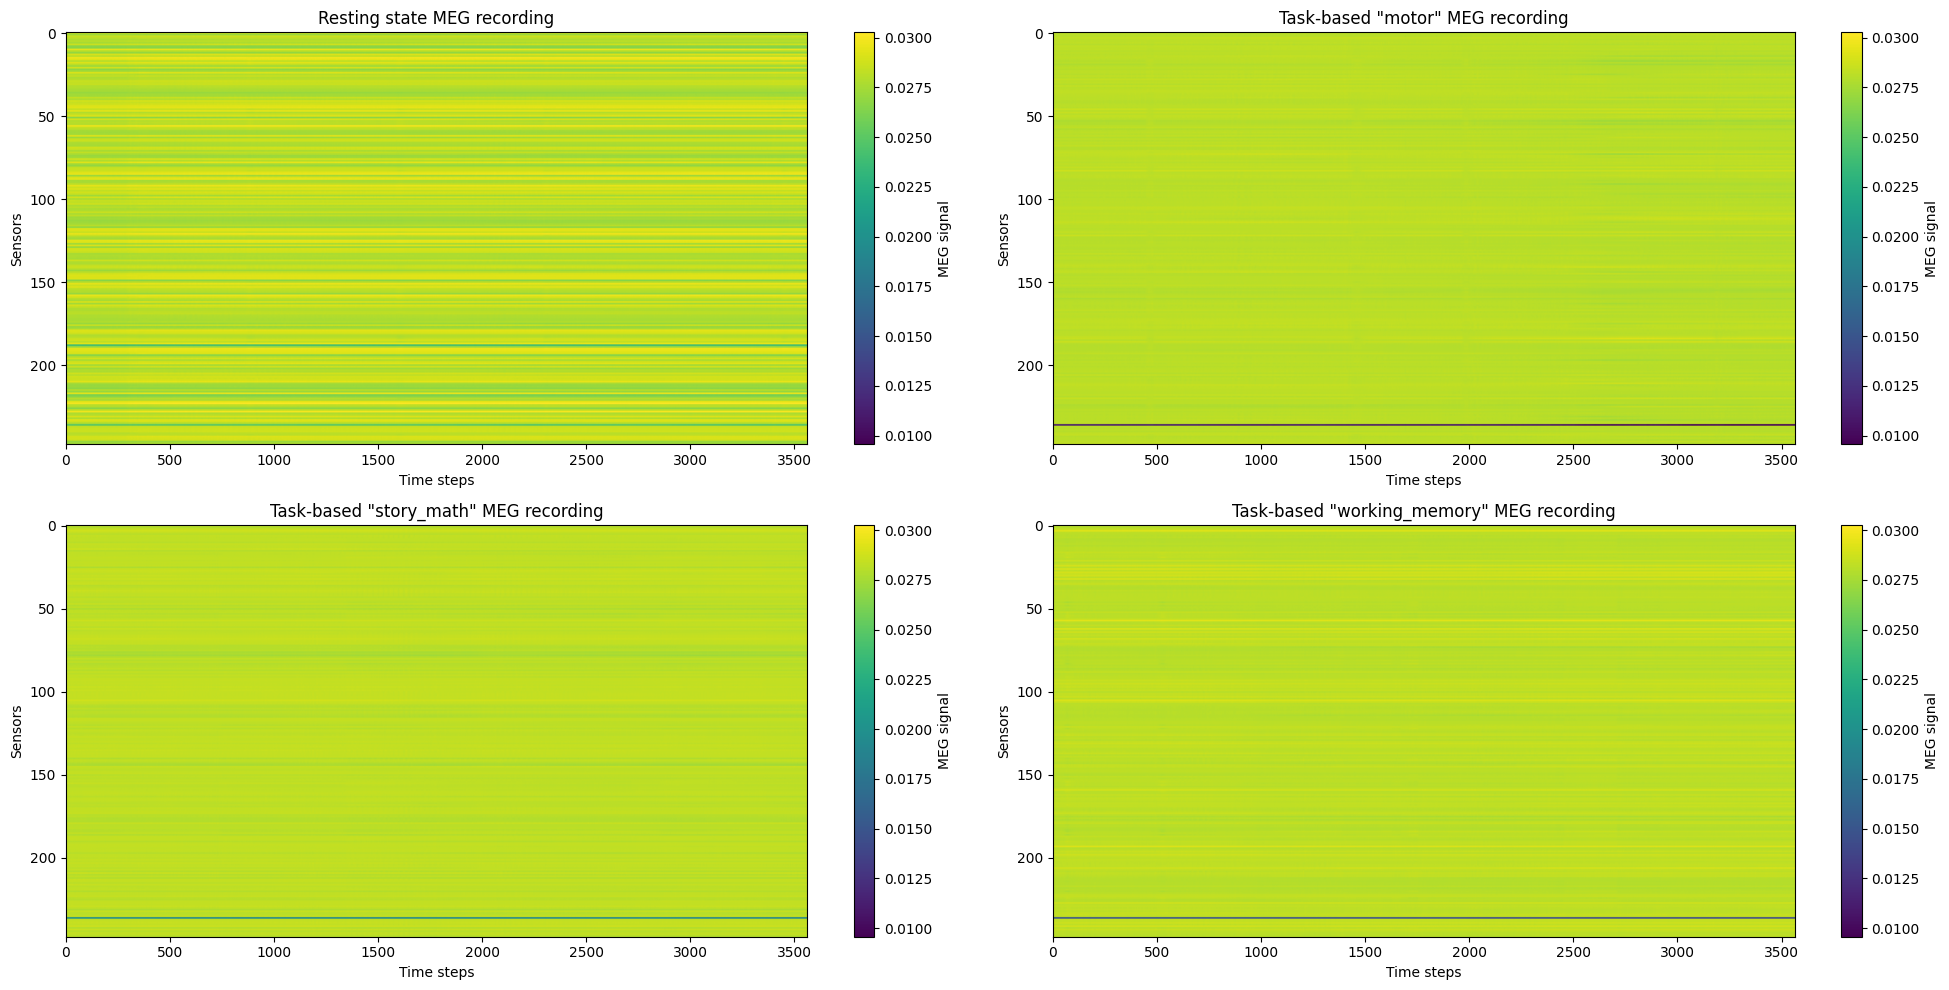

In [ ]:
dir_root = "/Users/stijnroos/VisualStudio/DL_data/"

# FIRST PLOT FOR SUBJECT 1

files_to_plot = [
    ("rest_105923_1.h5", "Resting state MEG recording"),
    ("task_motor_105923_1.h5", 'Task-based "motor" MEG recording'),
    ("task_story_math_105923_1.h5", 'Task-based "story_math" MEG recording'),
    ("task_working_memory_105923_1.h5", 'Task-based "working_memory" MEG recording'),
]

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

data_arrays = []

# Load data from each file
for filename, title in files_to_plot:
    filepath = dir_root + "Intra/train_scaled_downsampled/" + filename
    
    if os.path.exists(filepath):
        with h5py.File(filepath, 'r') as f:
            # Get the one dataset in the file
            ds_name = list(f.keys())[0]
            data = f[ds_name][()]
            data_arrays.append(data)

# Plot all data on same scale
vmin = min(d.min() for d in data_arrays)
vmax = max(d.max() for d in data_arrays)

for ax, (data, (filename, title)) in zip(axes.flat, zip(data_arrays, files_to_plot)):
    im = ax.imshow(data, aspect='auto', vmin=vmin, vmax=vmax, cmap='viridis')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Time steps")
    ax.set_ylabel("Sensors")
    fig.colorbar(im, ax=ax, label="MEG signal")

plt.tight_layout()
plt.show()




# THEN PLOT FOR SUBJECT 5
files_to_plot = [
    ("rest_105923_5.h5", "Resting state MEG recording"),
    ("task_motor_105923_5.h5", 'Task-based "motor" MEG recording'),
    ("task_story_math_105923_5.h5", 'Task-based "story_math" MEG recording'),
    ("task_working_memory_105923_5.h5", 'Task-based "working_memory" MEG recording'),
]

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

data_arrays = []

# Load data from each file
for filename, title in files_to_plot:
    filepath = dir_root + "Intra/train_scaled_downsampled/" + filename
    
    if os.path.exists(filepath):
        with h5py.File(filepath, 'r') as f:
            # Get the one dataset in the file
            ds_name = list(f.keys())[0]
            data = f[ds_name][()]
            data_arrays.append(data)

# Plot all data on same scale
vmin = min(d.min() for d in data_arrays)
vmax = max(d.max() for d in data_arrays)

for ax, (data, (filename, title)) in zip(axes.flat, zip(data_arrays, files_to_plot)):
    im = ax.imshow(data, aspect='auto', vmin=vmin, vmax=vmax, cmap='viridis')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Time steps")
    ax.set_ylabel("Sensors")
    fig.colorbar(im, ax=ax, label="MEG signal")

plt.tight_layout()
plt.show()

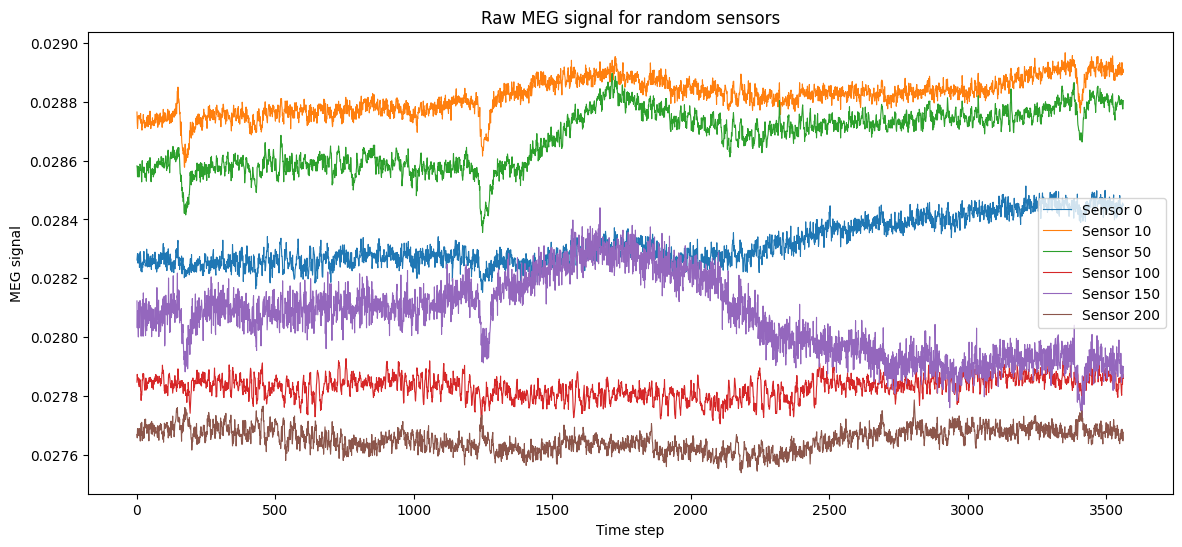

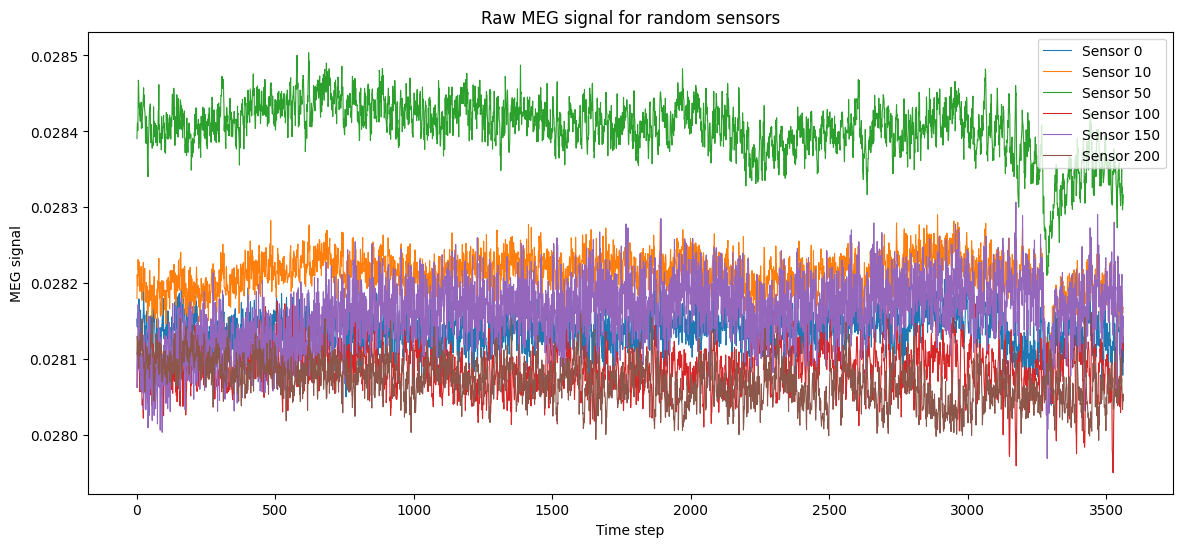

In [9]:
sensor_ids = [0, 10, 50, 100, 150, 200]

# read one of the files to get the matrix for plotting
file_to_read = dir_root + "Intra/train_scaled_downsampled/rest_105923_1.h5"
with h5py.File(file_to_read, 'r') as f:
    dataset_name = list(f.keys())[0]
    matrix = f[dataset_name][()]

plt.figure(figsize=(14, 6))
for sensor_id in sensor_ids:
    plt.plot(matrix[sensor_id], label=f"Sensor {sensor_id}", linewidth=0.8)

plt.xlabel("Time step")
plt.ylabel("MEG signal")
plt.title("Raw MEG signal for random sensors")
plt.legend()
plt.show()


# read one of the files to get the matrix for plotting
file_to_read = dir_root + "Intra/train_scaled_downsampled/task_motor_105923_1.h5"
with h5py.File(file_to_read, 'r') as f:
    dataset_name = list(f.keys())[0]
    matrix = f[dataset_name][()]

plt.figure(figsize=(14, 6))
for sensor_id in sensor_ids:
    plt.plot(matrix[sensor_id], label=f"Sensor {sensor_id}", linewidth=0.8)

plt.xlabel("Time step")
plt.ylabel("MEG signal")
plt.title("Raw MEG signal for random sensors")
plt.legend()
plt.show()

---
## Model training

### Scale the test data

In [7]:
# scale the test data using the min and max from the training data
dir_intra_test = dir_root + "Intra/test/"
dir_intra_test_scaled = dir_root + "Intra/test_scaled/"
scaler_stats_file = dir_root + "Intra/scaler_stats.json"

if not os.path.exists(dir_intra_test_scaled):
    os.makedirs(dir_intra_test_scaled)

    # Load global scaler stats from training data
    with open(scaler_stats_file, 'r') as f:
        scaler_stats = json.load(f)

    filenames = [f for f in os.listdir(dir_intra_test) if f.endswith('.h5')]

    for i, filename in enumerate(filenames):
        filepath_in = dir_intra_test + filename
        filepath_out = dir_intra_test_scaled + filename
        
        with h5py.File(filepath_in, 'r') as f_in:
            # Get the ONE dataset that exists in this file
            dataset_name = list(f_in.keys())[0]  # Get first (and only) key
            data = f_in[dataset_name][()]
            
            # Use global min/max from training data
            data_min = scaler_stats["global"]["min"]
            data_max = scaler_stats["global"]["max"]
            data_scaled = (data - data_min) / (data_max - data_min + 1e-8)
            
            # Save the scaled data
            with h5py.File(filepath_out, 'w') as f_out:
                # Keep the same dataset name for consistency
                f_out.create_dataset(dataset_name, data=data_scaled)
else:
    print("Directory already exists: skipping scaling step for test data")

### Intra-subject testing

In [ ]:
# train a model on the scaled training data and evaluate on the scaled test data
